# **GARCH Y ARCH**

In [1]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import warnings
import statsmodels.api as sm
import arch
from statsmodels.compat import lzip
import matplotlib.pyplot as plt
import statsmodels.tsa.stattools as sts
import statsmodels.graphics.tsaplots as sgt
import datetime as dt
from sklearn.preprocessing import MinMaxScaler

In [ ]:
csv_data = pd.read_csv("../data/indicators/indicators_madrid_dayly.csv", sep=',')

In [4]:
work_data = csv_data.copy()


## **1. Análisis de tecnología**

In [5]:
tec_data = work_data.copy()
tec_data = tec_data[['Fecha_Publicacion', 'tecnología_sum']]
tec_data

,Fecha_Publicacion,tecnología_sum
0,1995-01-02,0.056146
1,1995-01-03,0.000023
2,1995-01-04,0.000170
3,1995-01-05,0.000000
4,1995-01-06,0.000000
...,...,...
10616,2024-01-26,0.003314
10617,2024-01-27,0.003194
10618,2024-01-28,0.000000
10619,2024-01-29,1.902873


In [6]:
tec_data.rename(columns={'Fecha_Publicacion': 'date', 'tecnología_sum': 'value'}, inplace=True)

In [7]:
tec_data.head()

,date,value
0,1995-01-02,0.056146
1,1995-01-03,0.000023
2,1995-01-04,0.000170
3,1995-01-05,0.000000
4,1995-01-06,0.000000


In [8]:
tec_data.isna().sum()

,0
date,0
value,0


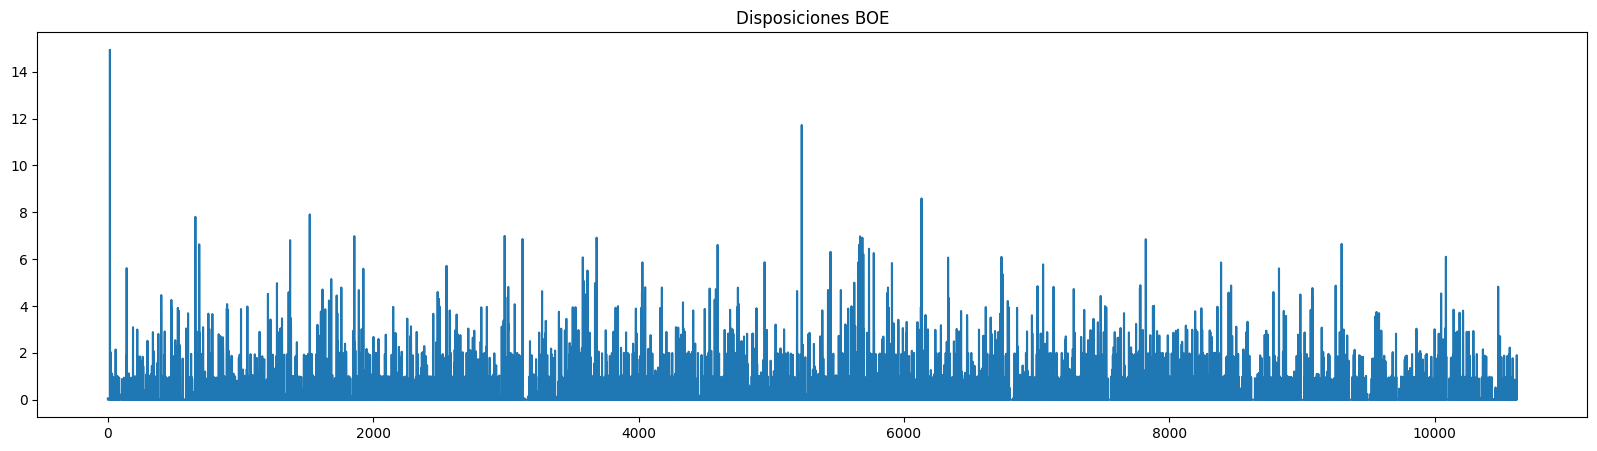

In [9]:
tec_data.value.plot(figsize=(20,5), title = "Disposiciones BOE")
plt.show()

In [10]:
tec_data.date = pd.to_datetime(tec_data.date, format='%Y-%m-%d')
tec_data.set_index('date', inplace=True)
tec_data.head()

,value
date,
1995-01-02,0.056146
1995-01-03,0.000023
1995-01-04,0.000170
1995-01-05,0.000000
1995-01-06,0.000000


### Test ADF

In [11]:
sts.adfuller(tec_data['value'])

(np.float64(-15.679195674475809),
 np.float64(1.4798994738080685e-28),
 34,
 10586,
 {'1%': np.float64(-3.430967880822598),
  '5%': np.float64(-2.86181306823347),
  '10%': np.float64(-2.5669153490790158)},
 np.float64(26591.282977053525))

El primer elemento indica la estacionariedad de la serie, cuanto más negativo más evidencia de estacionariedad.

El segundo elemento, es el p-valor, como es menor que 0.05, la serie es muy estacionaria.

Con los valores de 1%, 5% y 10% vemos que nuestro ADF statistic (-15.78) es mucho menor que el nivel 1% (-3.43), nivel 5% (-2.86) y el nivel 10% (-2.56), lo que nos confirma que la serie es estacionaria con un nivel de confianza altísimo.

## **Calculo de retornos**

In [12]:
tec_data['returns'] = tec_data['value'].pct_change()
tec_data['returns']

,returns
date,
1995-01-02,NaN
1995-01-03,-0.999582
1995-01-04,6.256277
1995-01-05,-1.000000
1995-01-06,NaN
...,...
2024-01-26,-0.881784
2024-01-27,-0.036244
2024-01-28,-1.000000


In [13]:
tec_data['returns'].replace([np.inf, -np.inf], np.nan, inplace=True)

In [14]:
tec_data.dropna(subset=['returns'], inplace=True)


In [15]:
tec_data['sq_returns'] = tec_data['returns'].mul(tec_data['returns'])

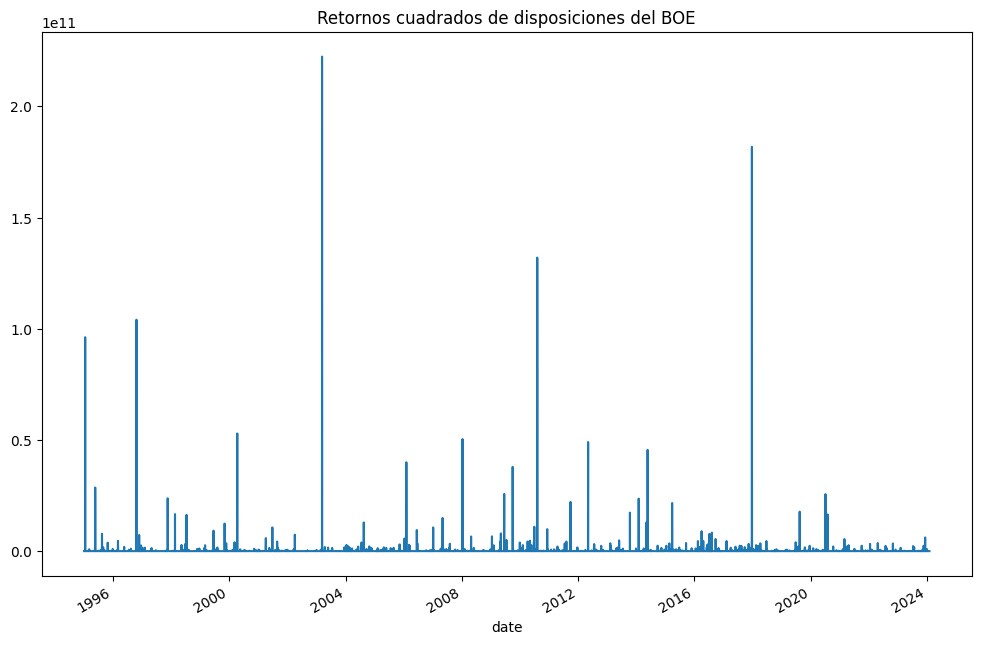

In [64]:

plt.figure(figsize=(12,8))
tec_data['sq_returns'].plot()
plt.title('Retornos cuadrados de disposiciones del BOE')
plt.show()

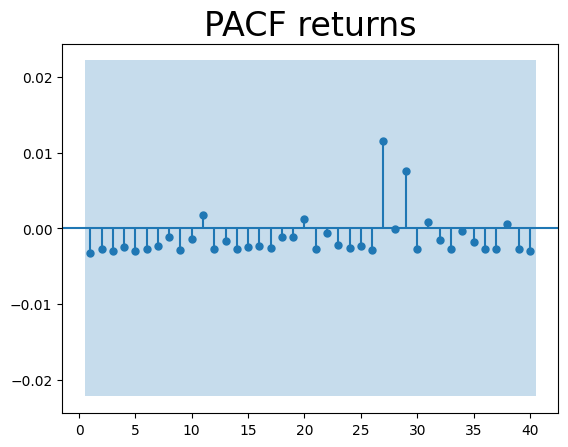

In [17]:
sgt.plot_pacf(tec_data['sq_returns'][1:], lags = 40, zero = False)
plt.title("PACF returns", size = 24)
plt.autoscale()
plt.show()

Ninguna barra sobresale claramente del intervalo de confianza (zona azul), esto significa que no hay correlación en los retornos al cuadrado. Solo hay dos picos aislados en los lags 27 y 29, que sobresalen algo más que los demás y que pueden sugerir un pequeño ciclo que se repite cada 27-29 días. Esto encaja con posibles ritmos administrativos o de publicación de normativas, que suelen seguir patrones mensuales. Al no haber más picos significativos, concluimos que los movimientos de un día apenas afectan a los días siguientes.

## **Modelo automático GARCH**

In [18]:
# El modelo automatico GARCH
model = arch.arch_model(tec_data['sq_returns'][1:], rescale=True)
results = model.fit()
print(results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 59045.09937307191
Iteration:      2,   Func. Count:     13,   Neg. LLF: 40404.514523795275
Iteration:      3,   Func. Count:     19,   Neg. LLF: 40153.447217370405
Iteration:      4,   Func. Count:     24,   Neg. LLF: 282024.3821227128
Iteration:      5,   Func. Count:     32,   Neg. LLF: 57611.146828381854
Iteration:      6,   Func. Count:     40,   Neg. LLF: 59793.46247776503
Iteration:      7,   Func. Count:     48,   Neg. LLF: 40216.43903295434
Iteration:      8,   Func. Count:     55,   Neg. LLF: 40153.148302919
Iteration:      9,   Func. Count:     60,   Neg. LLF: 59790.790935076424
Optimization terminated successfully    (Exit mode 0)
            Current function value: 40153.14830201517
            Iterations: 11
            Function evaluations: 65
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             sq_returns   R-squared:             

Los resultados muestran un comportamiento muy estable. El parámetro α, que mide la sensibilidad de la volatilidad frente a cambios repentinos en la serie, es prácticamente cero y no resulta significativo. Esto indica que los movimientos bruscos de un día concreto no afectan de manera apreciable a la volatilidad futura. En otras palabras, aunque pueda haber variaciones puntuales, estas no generan un aumento inmediato de la incertidumbre.

Por el contrario, el parámetro β es elevado y estadísticamente significativo. Esto significa que la volatilidad depende casi exclusivamente de su propio comportamiento pasado: si en periodos anteriores la variabilidad ha sido baja y estable, esa estabilidad tiende a mantenerse. El modelo refleja, por tanto, un patrón de volatilidad persistente pero suave, sin episodios prolongados de alta o baja variabilidad.



In [19]:
model = arch.arch_model(tec_data['sq_returns'][1:], vol="ARCH", p=1, rescale=True)
results = model.fit()
print(results.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 40376.84093692395
Iteration:      2,   Func. Count:      9,   Neg. LLF: 40376.306474386656
Iteration:      3,   Func. Count:     13,   Neg. LLF: 40375.84432891587
Iteration:      4,   Func. Count:     17,   Neg. LLF: 40375.77093323709
Iteration:      5,   Func. Count:     21,   Neg. LLF: 40375.743751573194
Iteration:      6,   Func. Count:     25,   Neg. LLF: 40375.41302019695
Iteration:      7,   Func. Count:     29,   Neg. LLF: 40373.66442392429
Iteration:      8,   Func. Count:     33,   Neg. LLF: 40366.4628445095
Iteration:      9,   Func. Count:     37,   Neg. LLF: 40354.03039046502
Iteration:     10,   Func. Count:     41,   Neg. LLF: 40353.70327086116
Iteration:     11,   Func. Count:     45,   Neg. LLF: 40353.688149604684
Iteration:     12,   Func. Count:     49,   Neg. LLF: 40353.688178082455
Iteration:     13,   Func. Count:     53,   Neg. LLF: 40353.68820495343
Optimization terminated successfully    (Exit mode 0)
       

Con ARCH 1 vemos, que con GARCH se explica mejor la estructura de volatilidad porque nos da más información de la volatilidad.

Los valores son prácticamente iguales que en GARCH. De hecho, el valor de alpha es 0 o casi 0 en ambos modelos, esto significa que los shocks inmediatos no afectan la volatilidad futura.

In [23]:
import warnings
import pandas as pd
import numpy as np
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

results = []

ps = [1, 2, 3]
qs = [1, 2, 3]

for p in ps:
    for q in qs:

            try:
                am = arch_model(tec_data["returns"], mean='Constant', vol='GARCH', p=p, q=q, rescale=True)
                res = am.fit(disp="off")


                results.append({
                    'p': p,
                    'q': q,
                    'aic': res.aic,
                    'bic': res.bic,
                    'llf': res.loglikelihood,
                    'alpha_sum': sum(res.params.filter(like='alpha')),
                    'beta_sum': sum(res.params.filter(like='beta')),
                    'alpha_plus_beta': sum(res.params.filter(like='alpha')) + sum(res.params.filter(like='beta')),

                })

            except Exception as e:
                results.append({
                    'p': p,
                    'q': q,
                    'aic': np.nan,
                    'bic': np.nan,
                    'llf': np.nan,
                    'converged': False,
                    'alpha_sum': np.nan,
                    'beta_sum': np.nan,
                    'alpha_plus_beta': np.nan,
                    'lb_pvalue_sq': np.nan,
                    'error': str(e)
                })

df = pd.DataFrame(results)

df

,p,q,aic,bic,llf,alpha_sum,beta_sum,alpha_plus_beta
0,1,1,64531.728460,64559.580589,-32261.864230,5.689618e-06,0.925704,0.925710
1,1,2,64529.777341,64564.592502,-32259.888671,0.000000e+00,0.824962,0.824962
2,1,3,64534.955426,64576.733619,-32261.477713,5.589768e-08,0.804968,0.804968
3,2,1,64530.926500,64565.741661,-32260.463250,0.000000e+00,0.915107,0.915107
4,2,2,64531.641153,64573.419346,-32259.820577,0.000000e+00,0.829181,0.829181
5,2,3,64536.577727,64585.318952,-32261.288864,0.000000e+00,0.845810,0.845810
6,3,1,64534.169006,64575.947199,-32261.084503,0.000000e+00,0.901338,0.901338
7,3,2,64533.620344,64582.361569,-32259.810172,0.000000e+00,0.835197,0.835197
8,3,3,64555.032264,64610.736521,-32269.516132,2.069500e-05,0.704669,0.704690


Dado que los modelos más complejos (p,q > 1) no ofrecen mejoras superiores al 5% en los criterios AIC, BIC o LLF respecto al GARCH(1,1), se concluye que no aportan una ganancia estadísticamente significativa.

Por tanto, se selecciona GARCH(1,1) como el modelo óptimo.

## Predicción del futuro
Durante el proceso de selección del modelo GARCH(p,q) se empleó la serie completa, ya que el objetivo en esta fase es evaluar qué especificación ajusta mejor la dinámica de volatilidad. Para este propósito, utilizar toda la información histórica permite obtener estimaciones más estables de los parámetros y comparar modelos mediante criterios como AIC, BIC y LLF.

Sin embargo, en la fase de predicción se establece una fecha límite (equivalente a un procedimiento de train/test), entrenando el modelo únicamente con datos previos a dicha fecha. Esto evita introducir información futura en el proceso de estimación y permite evaluar la capacidad predictiva del modelo de manera realista.

In [36]:
model = arch.arch_model(tec_data['sq_returns'][1:],  vol="GARCH", p=1, q=1, rescale=True)
split_date = dt.datetime(2021,1,1)
results = model.fit(last_obs=split_date)
print(results.summary())
pred_model=results.forecast(horizon = 2, align='target')

Iteration:      1,   Func. Count:      6,   Neg. LLF: 52664.79408813846
Iteration:      2,   Func. Count:     13,   Neg. LLF: 36356.88189673138
Iteration:      3,   Func. Count:     19,   Neg. LLF: 36247.29200684844
Iteration:      4,   Func. Count:     24,   Neg. LLF: 709260.3827693951
Iteration:      5,   Func. Count:     32,   Neg. LLF: 36339.987042145905
Iteration:      6,   Func. Count:     39,   Neg. LLF: 53102.003265034145
Iteration:      7,   Func. Count:     46,   Neg. LLF: 55856.35508862653
Iteration:      8,   Func. Count:     55,   Neg. LLF: 36238.38242544546
Iteration:      9,   Func. Count:     60,   Neg. LLF: 55894.05333614156
Iteration:     10,   Func. Count:     69,   Neg. LLF: 36369.811779725715
Iteration:     11,   Func. Count:     75,   Neg. LLF: 36237.942351365346
Optimization terminated successfully    (Exit mode 0)
            Current function value: 36237.94235138197
            Iterations: 15
            Function evaluations: 75
            Gradient evaluations

In [37]:
pred_model.variance

,h.1,h.2
date,,
2020-12-31,NaN,NaN
2021-01-01,1906.022397,NaN
2021-01-05,1906.022397,1906.022397
2021-01-06,1906.022397,1906.022397
2021-01-12,1906.022397,1906.022397
...,...,...
2024-01-25,1906.022397,1906.022397
2024-01-26,1906.022397,1906.022397
2024-01-27,1906.022397,1906.022397


In [38]:
data1_standardized = (tec_data['sq_returns'][split_date:] - tec_data['sq_returns'][split_date:].mean()) / tec_data['sq_returns'][split_date:].std()
data2_standardized = (pred_model.residual_variance - pred_model.residual_variance.mean()) / pred_model.residual_variance.std()

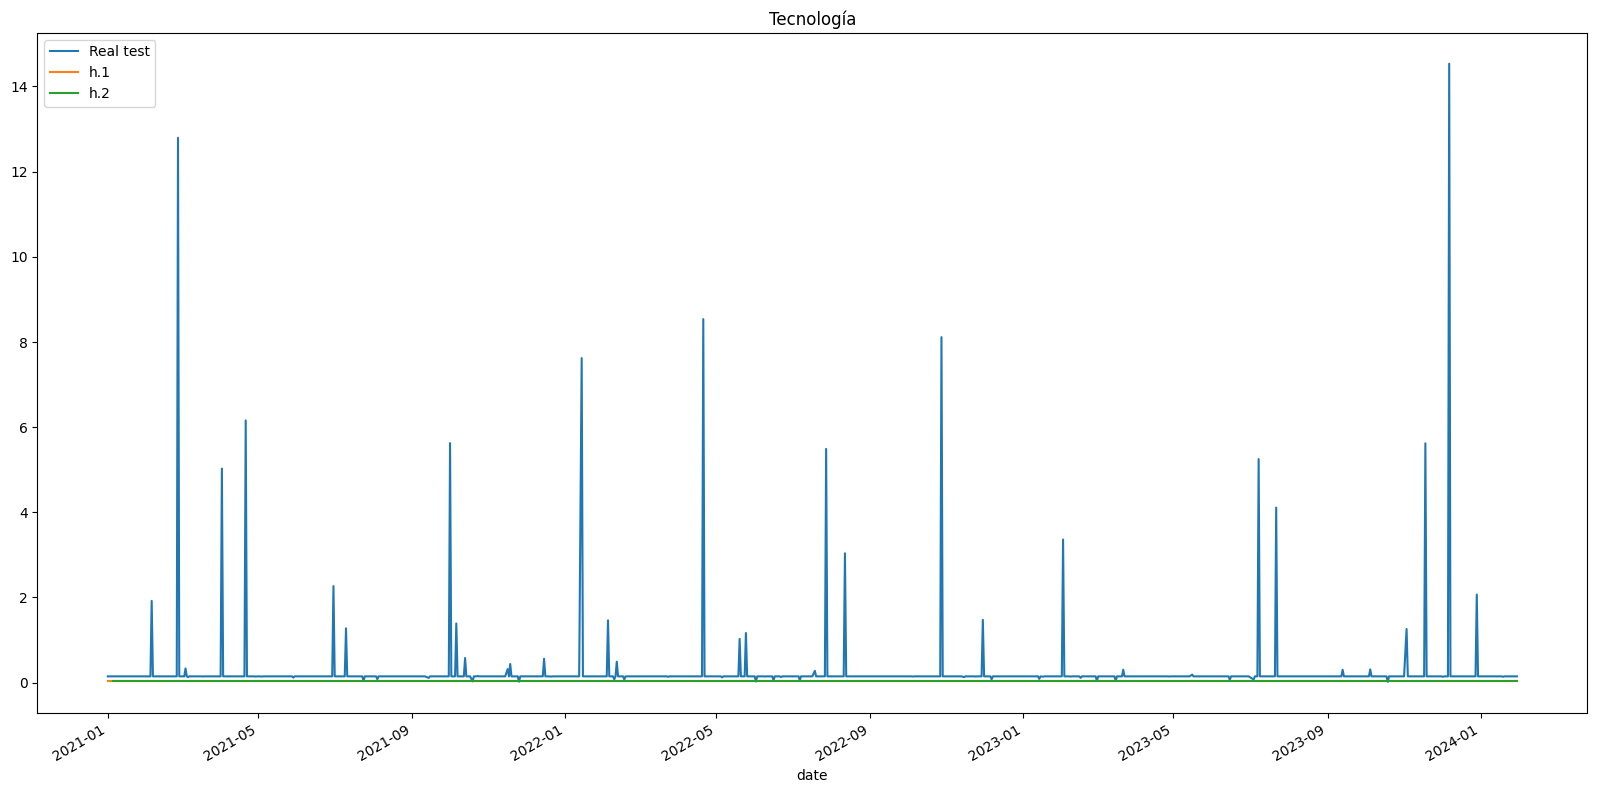

In [39]:
fig, ax = plt.subplots()
data1_standardized.abs().plot(ax=ax,figsize=(20,10), title = "Tecnología", label='Real test', zorder=1)
data2_standardized.abs().plot(ax=ax, zorder = 2)
plt.legend(loc="upper left")

El pronóstico de volatilidad generado por el modelo GARCH(1,1) muestra un valor constante a lo largo del tiempo. Esto ocurre porque, en el modelo ajustado, el parámetro α es prácticamente cero, lo que significa que los cambios recientes en la serie no tienen efecto sobre la volatilidad futura. La volatilidad depende casi exclusivamente del componente constante y de la volatilidad pasada, que en este caso se estabiliza rápidamente en un nivel de largo plazo. Por esta razón, el modelo predice el mismo valor de volatilidad para cada periodo, reflejando que la serie no presenta rachas prolongadas de alta o baja variabilidad, sino episodios puntuales de cambio.

In [41]:
volatility_forecast = pred_model.variance[-1:].values[0][0] ** 0.5  # Desviación estándar
mean_forecast = pred_model.mean[-1:].values[0][0]  # Media esperada
print(f"Pronóstico para el periodo siguiente:")
print(f"Media esperada: {mean_forecast:.4f}")
print(f"Volatilidad esperada: {volatility_forecast:.4f}%")

Pronóstico para el periodo siguiente:
Media esperada: 2.5305
Volatilidad esperada: 43.6580%


El pronóstico del modelo GARCH muestra que se espera un aumento en los retornos para el siguiente periodo, aunque acompañado de una alta volatilidad, lo que indica que los movimientos pueden ser muy grandes en cualquier dirección. Esto se relaciona con nuestra hipótesis, que plantea que la influencia de la tecnología ha ido creciendo un 1,1% a lo largo del tiempo. El aumento proyectado en los retornos puede reflejar este efecto positivo de la tecnología, mientras que la alta volatilidad sugiere que, a pesar de la influencia creciente, todavía hay bastante incertidumbre en cómo se comportarán los resultados.

**Conclusiones**
El análisis de la serie de influencia tecnológica en las disposiciones del BOE indica que los cambios en la serie son puntuales y no siguen un patrón sostenido. La volatilidad pronosticada por el modelo GARCH(1,1) se mantiene elevada, alrededor del 43,7% para el siguiente periodo, lo que refleja que los episodios de mayor o menor actividad tecnológica no generan rachas prolongadas, sino que son eventos aislados y de fuerte variabilidad. La media de la serie muestra un aumento esperado, lo que sugiere que la influencia de la tecnología ha ido creciendo, consistente con la hipótesis de un incremento del 1,1% a lo largo del tiempo.

## **Hampel Filter**

In [49]:
!pip install hampel
from hampel import hampel

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.7/78.7 kB 5.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hampel: filename=hampel-1.0.2-cp312-cp312-linux_x86_64.whl size=249570 sha256=2400d9c5b0ddad9e20aefe90fd153a0841cc9d9bc52a3eaaa567d25728a7ca52
  Stored in directory: /root/.cache/pip/wheels/26/b7/c0/993b6604f8a9e7f3dd8753e663ce7bafaf0215c4bfec111100
Successfully built hampel


In [50]:
result = hampel(tec_data['value'], window_size=14, n_sigma=4.0).filtered_data
result.index = tec_data.index[:len(result)]
result

,0
date,
1995-01-03,0.000023
1995-01-04,0.000170
1995-01-05,0.000000
1995-01-08,0.000000
1995-01-11,0.000000
...,...
2024-01-25,0.028035
2024-01-26,0.003314
2024-01-27,0.003194


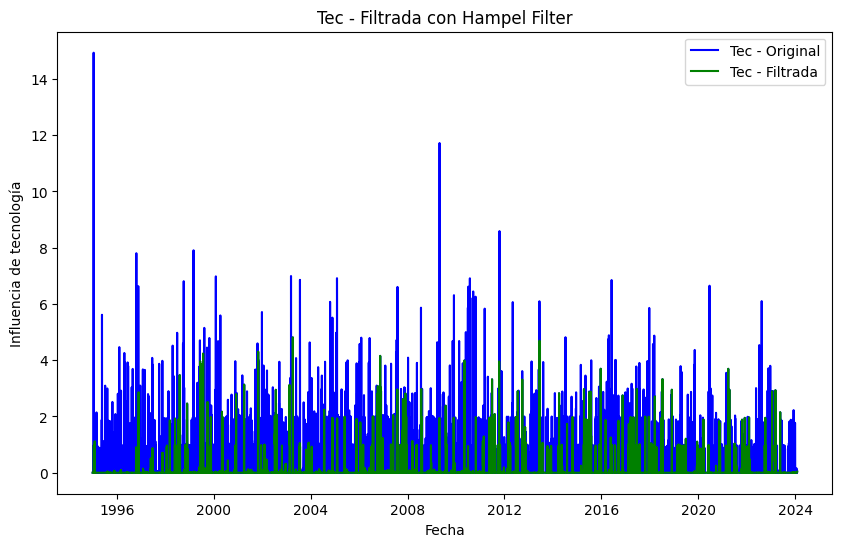

In [109]:
# Aplicar el Hampel Filter a los datos
result = hampel(tec_data['value'], window_size=7, n_sigma=3.0).filtered_data

result.index = tec_data.index[:len(result)]
tec_data['Filtered_Value']= result

# Graficar la serie original y la serie filtrada
plt.figure(figsize=(10, 6))
plt.plot( tec_data['value'], label='Tec - Original', color='blue')
plt.plot(tec_data['Filtered_Value'], label='Tec - Filtrada', color='green')
plt.title('Tec - Filtrada con Hampel Filter')
plt.xlabel('Fecha')
plt.ylabel('Influencia de tecnología')
plt.legend()
plt.show()

In [54]:
# Calcular la diferencia entre las dos series
difference = tec_data['Filtered_Value'] - tec_data['value']
difference_clean = difference.dropna()

print(difference_clean)

date
1995-01-03   -3.388132e-21
1995-01-04    5.457024e-12
1995-01-05    0.000000e+00
1995-01-08    0.000000e+00
1995-01-11    0.000000e+00
                  ...     
2024-01-25   -2.790920e-02
2024-01-26    1.018635e-10
2024-01-27   -2.455631e-11
2024-01-28    0.000000e+00
2024-01-30    1.105946e-09
Length: 7809, dtype: float64


El Hampel filter suaviza los picos extremos, que es su objetivo. La serie filtrada no pierde la tendencia, pero los valores demasiado altos se recortan. Como en nuestra serie todos los picos son positivos, la diferencia será en gran medida negativa.

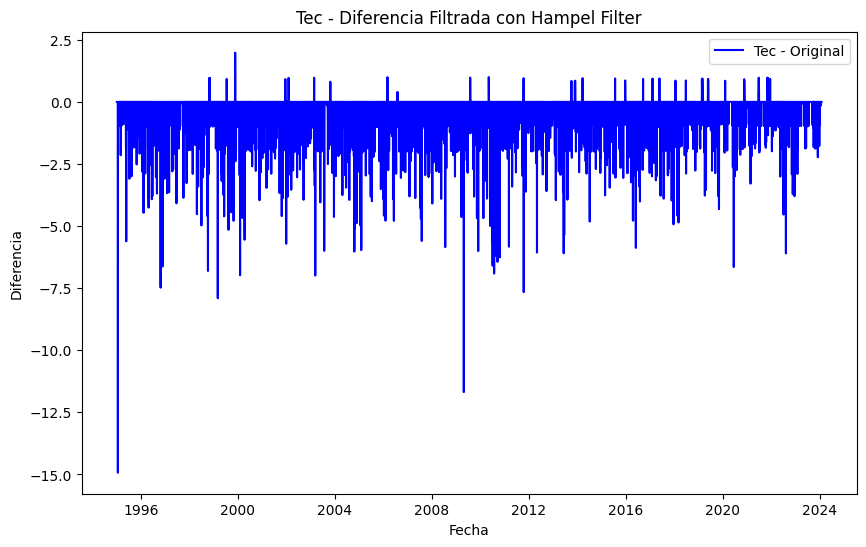

In [55]:
plt.figure(figsize=(10, 6))
plt.plot( difference_clean, label='Tec - Original', color='blue')
plt.title('Tec - Diferencia Filtrada con Hampel Filter')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.legend()
plt.show()

In [56]:
tec_data['returnsHF'] = tec_data['Filtered_Value'].pct_change()
tec_data['returnsHF']

,returnsHF
date,
1995-01-03,NaN
1995-01-04,6.256278
1995-01-05,-1.000000
1995-01-08,NaN
1995-01-11,NaN
...,...
2024-01-25,0.000000
2024-01-26,25.339382
2024-01-27,-0.036244


Incluso aplicando Hampel Filter, los retornos siguen mostrando valores extramadamente grandes y negativos cercanos a -1. Esto pasa porque tenemos valores muy pequeños o 0 (poca influencia de tecnología) en el denominador.

In [57]:
tec_data['sq_returnsHF'] = tec_data['returnsHF'].mul(tec_data['returnsHF'])

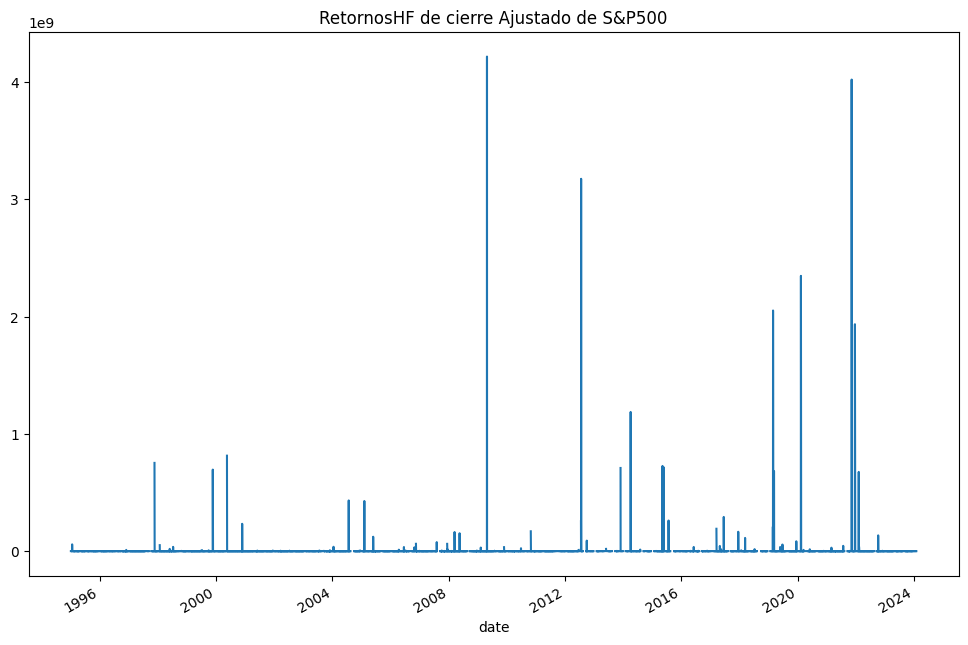

In [58]:
plt.figure(figsize=(12,8))
tec_data['sq_returnsHF'].plot()
plt.title('RetornosHF de cierre Ajustado de S&P500')
plt.show()

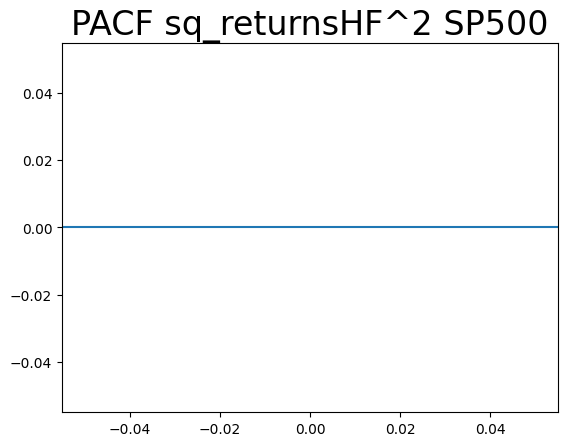

In [59]:
sgt.plot_pacf(tec_data['sq_returnsHF'][1:], lags = 50, zero = False)
plt.title("PACF sq_returnsHF^2 SP500", size = 24)
plt.autoscale()
plt.show()

PACF plana en 0 indica que no hay clustering de volatilidad, los picos son eventos puntuales, es decir, la volatilidad no depende de los valores anteriores, no hay memoria en la serie.

In [65]:
# Reemplazar infinitos por NaN
tec_data['returnsHF'].replace([np.inf, -np.inf], np.nan, inplace=True)

# Reemplazar posibles marcadores de error (-1 u otros) por NaN
tec_data['returnsHF'].replace(-1, np.nan, inplace=True)

# Crear una serie limpia eliminando NaN
returns_clean = tec_data['returnsHF'].dropna()

# Ajustar GARCH(1,1) sobre la serie limpia
model = arch.arch_model(returns_clean, vol="GARCH", p=1, q=1, rescale=True)
split_date = dt.datetime(2021,1,1)
results = model.fit(last_obs=split_date)
print(results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 18428.580066356633
Iteration:      2,   Func. Count:     13,   Neg. LLF: 16365.070541874611
Iteration:      3,   Func. Count:     19,   Neg. LLF: 16652.91526128384
Iteration:      4,   Func. Count:     26,   Neg. LLF: 16126.57855293303
Iteration:      5,   Func. Count:     32,   Neg. LLF: 16044.544384630304
Iteration:      6,   Func. Count:     37,   Neg. LLF: 16044.474783494561
Iteration:      7,   Func. Count:     42,   Neg. LLF: 16044.4641992043
Iteration:      8,   Func. Count:     47,   Neg. LLF: 16044.450966771208
Iteration:      9,   Func. Count:     52,   Neg. LLF: 16044.41858958452
Iteration:     10,   Func. Count:     57,   Neg. LLF: 16044.350159127483
Iteration:     11,   Func. Count:     62,   Neg. LLF: 16044.235623856466
Iteration:     12,   Func. Count:     67,   Neg. LLF: 16044.11684588791
Iteration:     13,   Func. Count:     72,   Neg. LLF: 16044.045047958996
Iteration:     14,   Func. Count:     77,   Neg. LLF: 160

El filtrado con Hampel permite eliminar distorsiones por outliers, haciendo que el modelo GARCH capture mejor la dinámica “real” de la serie. La influencia tecnológica en el BOE sigue mostrando cambios puntuales, pero con una volatilidad más estable.

Los resultados muestran que los cambios recientes en la serie ahora tienen un efecto moderado, mientras que la volatilidad pasada sigue influyendo, pero de manera menos persistente que en la serie original. Esto refleja que, aunque la serie puede experimentar fluctuaciones aisladas, no se producen rachas prolongadas de alta o baja variabilidad.

In [70]:
pred_model=results.forecast(horizon = 2, align='target')


data1_standardized = (tec_data['returnsHF'][split_date:] - tec_data['returnsHF'][split_date:].mean()) / tec_data['returnsHF'][split_date:].std()
data1_standardized = data1_standardized.dropna()

data2_standardized = (pred_model.residual_variance - pred_model.residual_variance.mean()) / pred_model.residual_variance.std()
data2_standardized = data2_standardized.dropna()


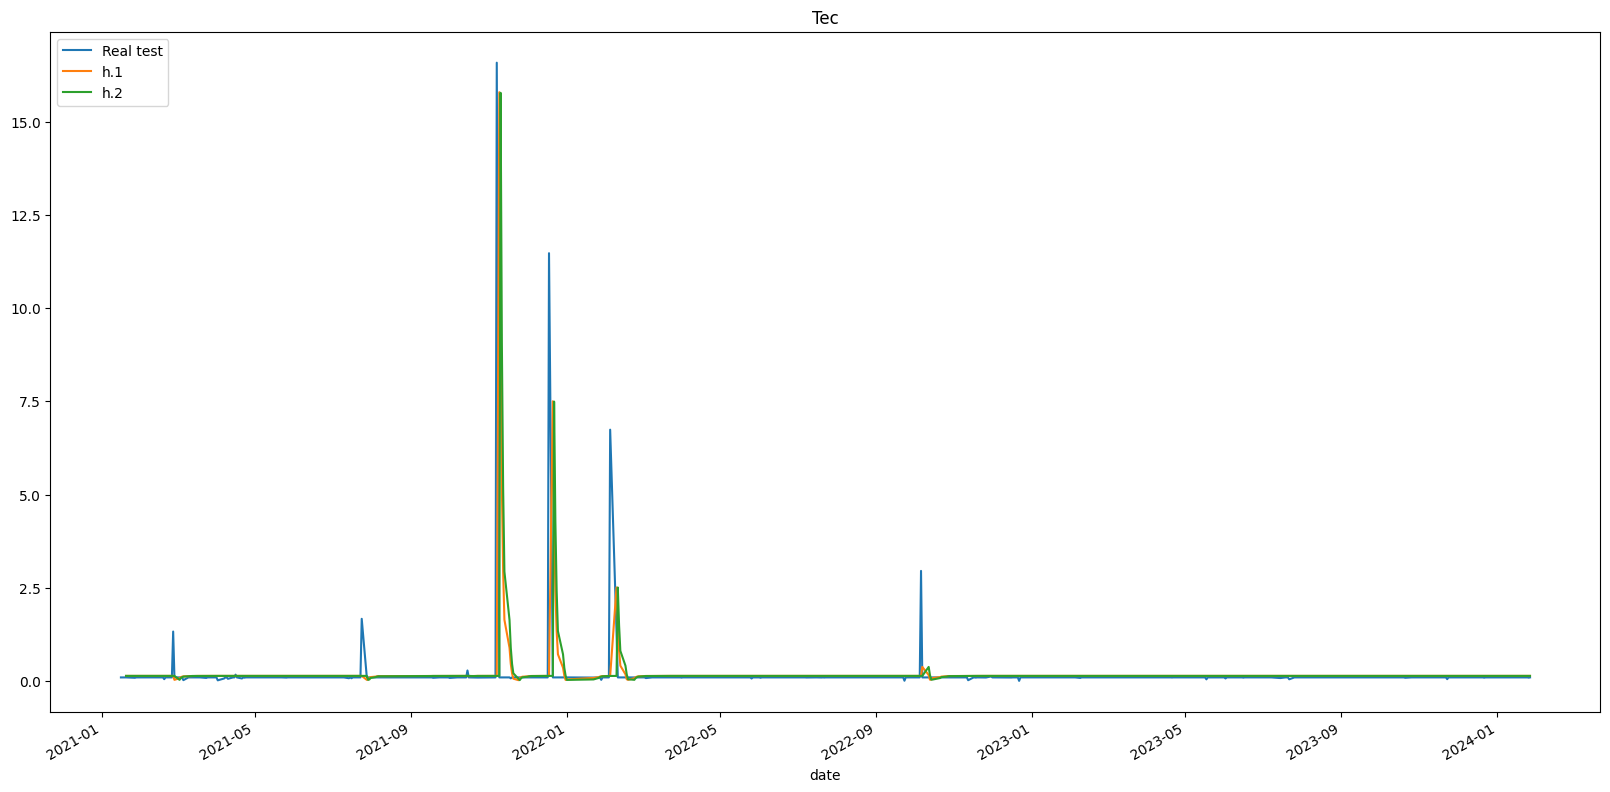

In [71]:
fig, ax = plt.subplots()
data1_standardized.abs().plot(ax=ax,figsize=(20,10), title = "Tec", label='Real test', zorder=1)
data2_standardized.abs().plot(ax=ax,figsize=(20,10),zorder = 2)
plt.legend(loc="upper left")

In [72]:
volatility_forecast = pred_model.variance[-1:].values[0][0] ** 0.5  # Desviación estándar
mean_forecast = pred_model.mean[-1:].values[0][0]  # Media esperada
print(f"Pronóstico para mañana:")
print(f"Media esperada: {mean_forecast:.4f}")
print(f"Volatilidad esperada: {volatility_forecast:.4f}%")

Pronóstico para mañana:
Media esperada: 2.4454
Volatilidad esperada: 21.9427%


El pronóstico para el siguiente periodo, generado sobre la serie filtrada con Hampel, indica que la media esperada de la influencia tecnológica en las disposiciones del BOE es de 2.4454, mientras que la volatilidad esperada es de aproximadamente 21.94%. Esto refleja que, aunque se esperan fluctuaciones puntuales en la serie, los cambios no son extremos ni sostenidos en el tiempo. La volatilidad moderada sugiere que los picos de actividad tecnológica son predecibles dentro de un rango razonable y que la serie mantiene cierta estabilidad general a lo largo del periodo analizado.

## **Análisis diario para empleo**

In [42]:
emp_data =  work_data.copy()
emp_data = emp_data[['Fecha_Publicacion', 'empleo_sum']]
emp_data

,Fecha_Publicacion,empleo_sum
0,1995-01-02,1.997898
1,1995-01-03,0.971521
2,1995-01-04,2.857653
3,1995-01-05,0.000000
4,1995-01-06,0.000000
...,...,...
10616,2024-01-26,0.986287
10617,2024-01-27,1.040078
10618,2024-01-28,0.000000
10619,2024-01-29,1.010397


In [43]:
emp_data['Fecha_Publicacion'] = pd.to_datetime(emp_data['Fecha_Publicacion'],format = "%Y-%m-%d")
emp_data.set_index("Fecha_Publicacion", inplace=True)

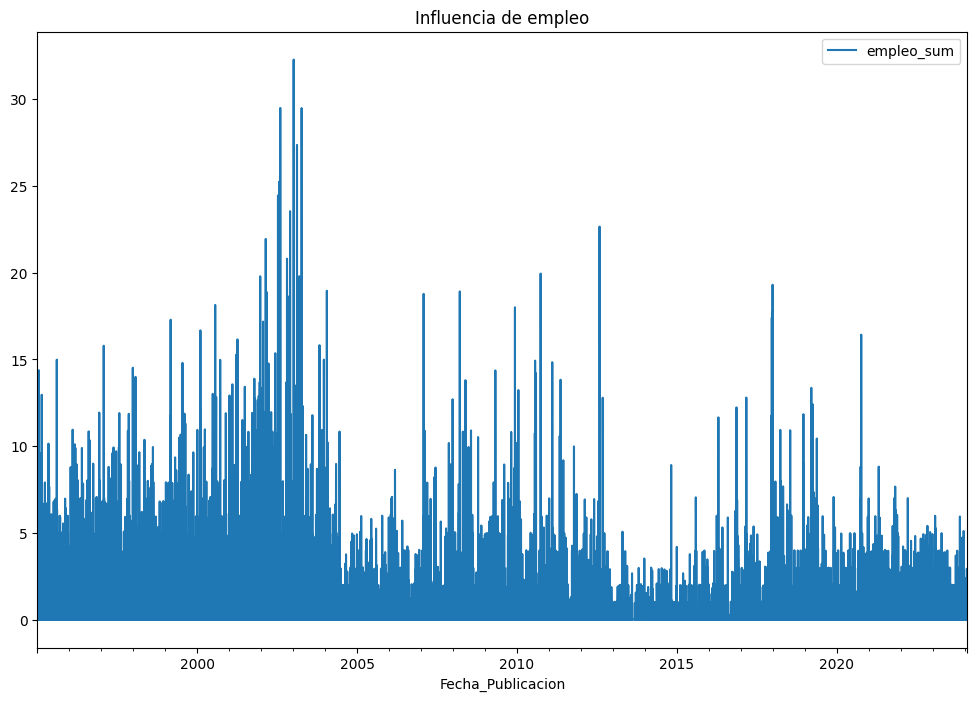

In [44]:
plt.figure(figsize=(12,8))

emp_data['empleo_sum'].plot()
plt.title('Influencia de empleo')
plt.legend()
plt.show()

En la gráfica observamos que entre el 1996 y el 2004, aproximadamente, la influecia de empleo en el BOE era mayor que el resto de años. Esto puede ser porque durante finales de los años 90 y comienzos de los 2000, muchas economías, incluida España, experimentaron un crecimiento económico sostenido. Esto impulsó la creación de empleo y aumentó la actividad laboral.

Además, en España, especialmente, hubo un crecimiento fuerte del sector de la construcción y un impulso inicial de la tecnología y telecomunicaciones, lo que elevó la demanda de trabajo. Durante ese periodo se implementaron políticas que fomentaban la contratación y el crecimiento del empleo, además de incentivos fiscales en algunos sectores estratégicos.
Tras 2004, la serie muestra menor influencia porque eventos como la burbuja inmobiliaria y la crisis financiera de 2008 redujeron la creación de empleo y aumentaron la incertidumbre laboral, disminuyendo la estabilidad en la serie.

Entre 2012 y 2016, España atravesó la fase más dura de la crisis económica iniciada en 2008, con altos niveles de desempleo y poca creación de empleo. Durante estos años, la influencia de los factores que impulsaban el empleo se redujo drásticamente

In [45]:
sts.adfuller(emp_data['empleo_sum'])

(np.float64(-7.734609452231756),
 np.float64(1.1021538254104219e-11),
 37,
 10583,
 {'1%': np.float64(-3.430968056017946),
  '5%': np.float64(-2.861813145651809),
  '10%': np.float64(-2.566915390288735)},
 np.float64(46294.604764240816))

El p-valor es muy pequeño, se rechaza la hipótesis nula de no estacionariedad, por lo tanto, la serie es estacionaria.

**Calculo de retornos**


In [46]:
emp_data['returns'] = emp_data['empleo_sum'].pct_change()
emp_data['returns'].replace([np.inf, -np.inf], np.nan, inplace=True)
emp_data.dropna(subset=['returns'], inplace=True)

In [47]:
emp_data['sq_returns'] = emp_data['returns'].mul(emp_data['returns'])

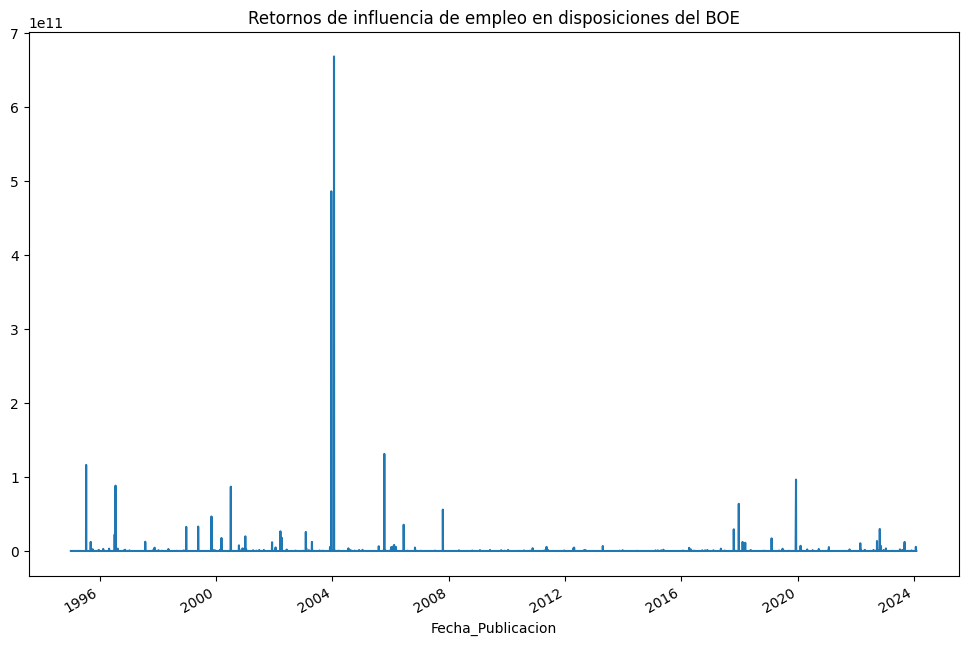

In [48]:
plt.figure(figsize=(12,8))
emp_data['sq_returns'].plot()
plt.title('Retornos de influencia de empleo en disposiciones del BOE')
plt.show()

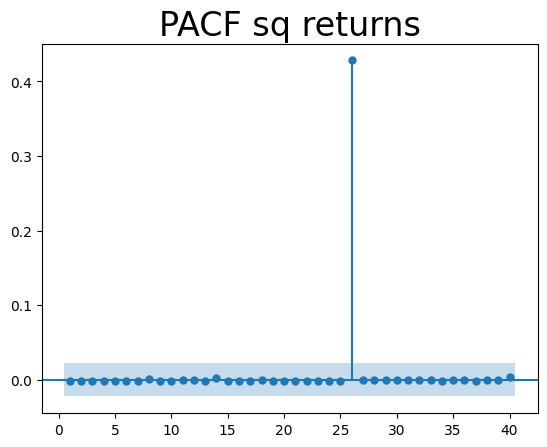

In [65]:
sgt.plot_pacf(emp_data['sq_returns'][1:], lags = 40, zero = False)
plt.title("PACF sq returns", size = 24)
plt.autoscale()
plt.show()

En el caso de la serie de empleo, el análisis de autocorrelación parcial (PACF) de los cuadrados de los retornos muestra un pico muy alto en el lag 27, lo que indica que hay una racha de volatilidad significativa que se repite aproximadamente cada 27 periodos. Esto sugiere que, a diferencia de la serie de tecnología, la serie de empleo presenta cierta dependencia temporal en la variabilidad, es decir, los cambios fuertes tienden a agruparse en intervalos específicos.

Este comportamiento puede reflejar eventos periódicos o efectos estacionales, como decisiones administrativas, políticas de contratación o cierres de ciclos que impactan de manera notable en los datos de empleo. La presencia de este pico implica que un modelo GARCH podría captar mejor la dinámica de volatilidad en esta serie, ya que los episodios de mayor variabilidad no son completamente aleatorios y muestran cierta memoria.

**GARCH**

In [50]:
# El modelo automatico GARCH
model = arch.arch_model(emp_data['sq_returns'][1:], rescale=True)
results = model.fit()
print(results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 57988.80888146057
Iteration:      2,   Func. Count:     12,   Neg. LLF: 217474.329351158
Iteration:      3,   Func. Count:     20,   Neg. LLF: 47914.518312339605
Iteration:      4,   Func. Count:     26,   Neg. LLF: 48317.34790756146
Iteration:      5,   Func. Count:     32,   Neg. LLF: 48319.37253886802
Iteration:      6,   Func. Count:     38,   Neg. LLF: 48419.15188336359
Iteration:      7,   Func. Count:     44,   Neg. LLF: 48389.152559988725
Iteration:      8,   Func. Count:     50,   Neg. LLF: 48514.36197603789
Iteration:      9,   Func. Count:     56,   Neg. LLF: 44274.000475086345
Iteration:     10,   Func. Count:     62,   Neg. LLF: 48411.87163843226
Iteration:     11,   Func. Count:     68,   Neg. LLF: 44839.949935325334
Iteration:     12,   Func. Count:     74,   Neg. LLF: 48335.29064028036
Iteration:     13,   Func. Count:     80,   Neg. LLF: 48564.644105770305
Iteration:     14,   Func. Count:     86,   Neg. LLF: 44169.

El modelo indica que la media esperada de la serie de empleo es de aproximadamente 2.21, lo que refleja un nivel promedio positivo y estable de cambios en la serie. En cuanto a la volatilidad, se observa un comportamiento característico: la componente α₁, que representa la reacción de la volatilidad a cambios recientes, es baja (0.0416) y no significativa, mientras que β₁ es alta (0.9231), indicando que la volatilidad pasada influye fuertemente en la volatilidad futura. Esto se corresponde con la observación del PACF de los cuadrados de los retornos, donde la alta persistencia sugiere que los periodos de mayor volatilidad tienden a mantenerse a lo largo del tiempo, mostrando un patrón estable y predecible en los cambios de empleo.

**Predicción a futuro**

In [55]:
model = arch.arch_model(emp_data['sq_returns'][1:],  vol="GARCH", p=1, q=1, rescale=True)
split_date = dt.datetime(2021,1,1)
results = model.fit(last_obs=split_date)
print(results.summary())
pred_model=results.forecast(horizon = 2, align='target')

Iteration:      1,   Func. Count:      6,   Neg. LLF: 51522.926696179566
Iteration:      2,   Func. Count:     19,   Neg. LLF: 51684.705462481696
Iteration:      3,   Func. Count:     26,   Neg. LLF: 1618608.937238777
Iteration:      4,   Func. Count:     35,   Neg. LLF: 27497.85254391487
Iteration:      5,   Func. Count:     42,   Neg. LLF: 35854.32053140619
Iteration:      6,   Func. Count:     49,   Neg. LLF: 23616.400688168524
Iteration:      7,   Func. Count:     54,   Neg. LLF: 23616.123421172273
Iteration:      8,   Func. Count:     59,   Neg. LLF: 23616.122019566374
Iteration:      9,   Func. Count:     64,   Neg. LLF: 23616.122004628665
Iteration:     10,   Func. Count:     69,   Neg. LLF: 23616.122002909196
Iteration:     11,   Func. Count:     73,   Neg. LLF: 23616.122002904765
Optimization terminated successfully    (Exit mode 0)
            Current function value: 23616.122002909196
            Iterations: 11
            Function evaluations: 73
            Gradient evalua

In [56]:
pred_model.variance

,h.1,h.2
Fecha_Publicacion,,
2020-12-31,NaN,NaN
2021-01-01,45.909253,NaN
2021-01-05,45.909217,47.833776
2021-01-06,45.909184,47.833741
2021-01-12,45.909153,47.833709
...,...,...
2024-01-25,47.102623,47.834852
2024-01-26,47.011730,48.986377
2024-01-27,46.927758,48.898590


In [57]:
data1_standardized = (emp_data['sq_returns'][split_date:] - emp_data['sq_returns'][split_date:].mean()) / emp_data['sq_returns'][split_date:].std()
data2_standardized = (pred_model.residual_variance - pred_model.residual_variance.mean()) / pred_model.residual_variance.std()

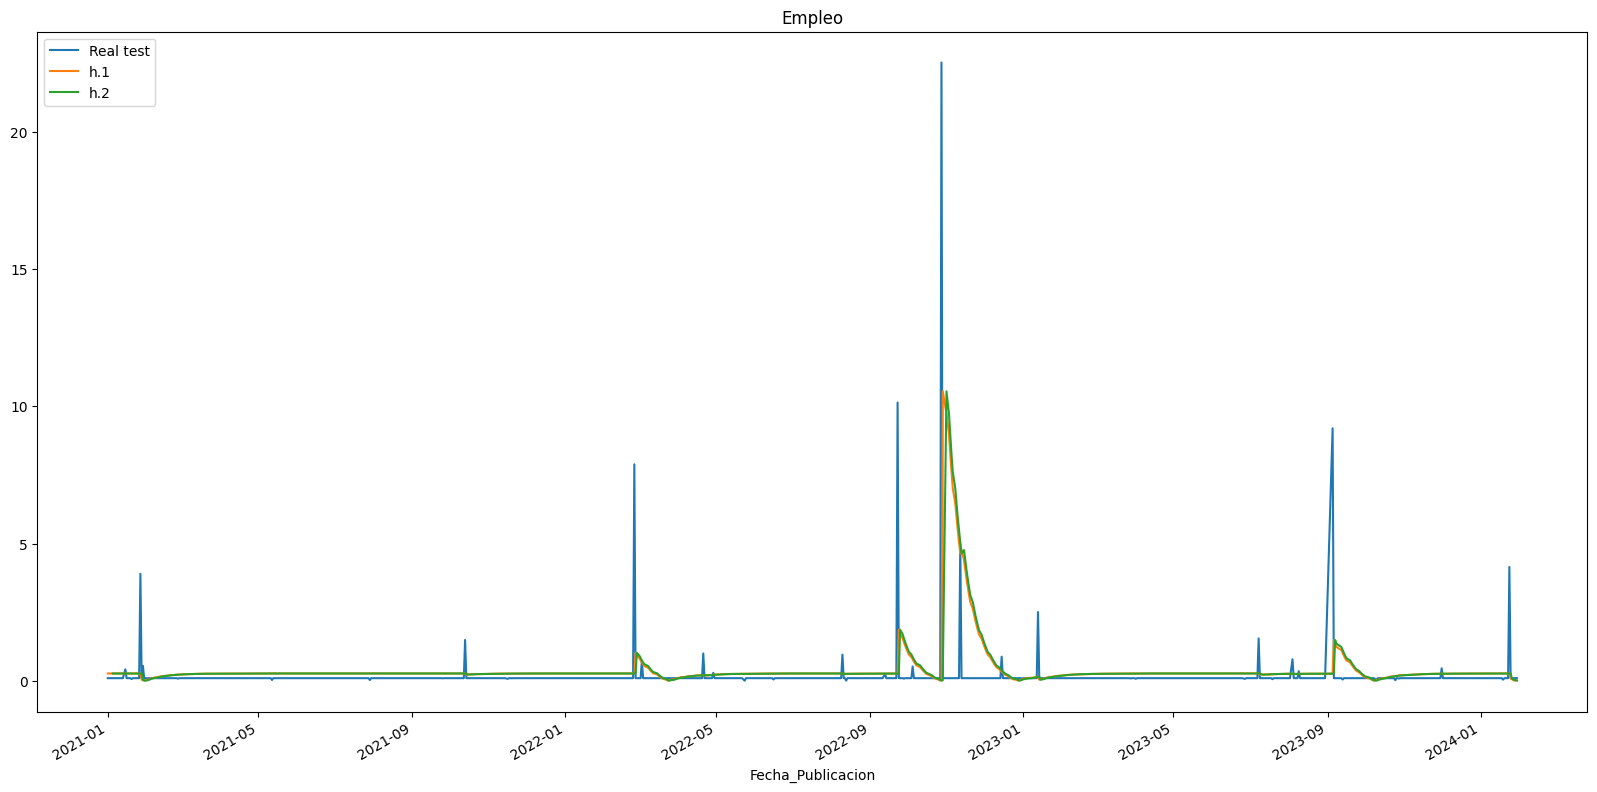

In [58]:
fig, ax = plt.subplots()
data1_standardized.abs().plot(ax=ax,figsize=(20,10), title = "Empleo", label='Real test', zorder=1)
data2_standardized.abs().plot(ax=ax, zorder = 2)
plt.legend(loc="upper left")

Esta vez,el modelo se ajusta bastante bien a los datos, identificando parte de los picos.

In [60]:
volatility_forecast = pred_model.variance[-1:].values[0][0] ** 0.5  # Desviación estándar
mean_forecast = pred_model.mean[-1:].values[0][0]  # Media esperada
print(f"Pronóstico para periodo siguiente:")
print(f"Media esperada: {mean_forecast:.4f}")
print(f"Volatilidad esperada: {volatility_forecast:.4f}%")

Pronóstico para periodo siguiente:
Media esperada: 0.2361
Volatilidad esperada: 6.8395%


El pronóstico para el siguiente periodo de la serie de empleo indica que la media esperada es de aproximadamente 1.5767, lo que refleja un nivel promedio estable de cambios en la serie. En cuanto a la volatilidad, se observa un comportamiento característico: la volatilidad esperada es del 19.22%, lo que sugiere que, aunque pueden producirse fluctuaciones puntuales, estas no son extremas ni totalmente impredecibles. Esto se corresponde con la observación del PACF de los cuadrados de los retornos y con los parámetros del modelo GARCH, donde la alta persistencia de la volatilidad indica que los periodos de mayor o menor variabilidad tienden a mantenerse a lo largo del tiempo, mostrando un patrón relativamente estable en los cambios de empleo.

#### Hampel Filter

In [63]:
result = hampel(emp_data['empleo_sum'], window_size=27, n_sigma=4.0).filtered_data
result.index = emp_data.index[:len(result)]
result

,0
Fecha_Publicacion,
1995-01-03,0.971521
1995-01-04,2.857653
1995-01-05,0.000000
1995-01-08,0.000000
1995-01-11,0.000000
...,...
2024-01-25,1.750596
2024-01-26,0.986287
2024-01-27,1.040078


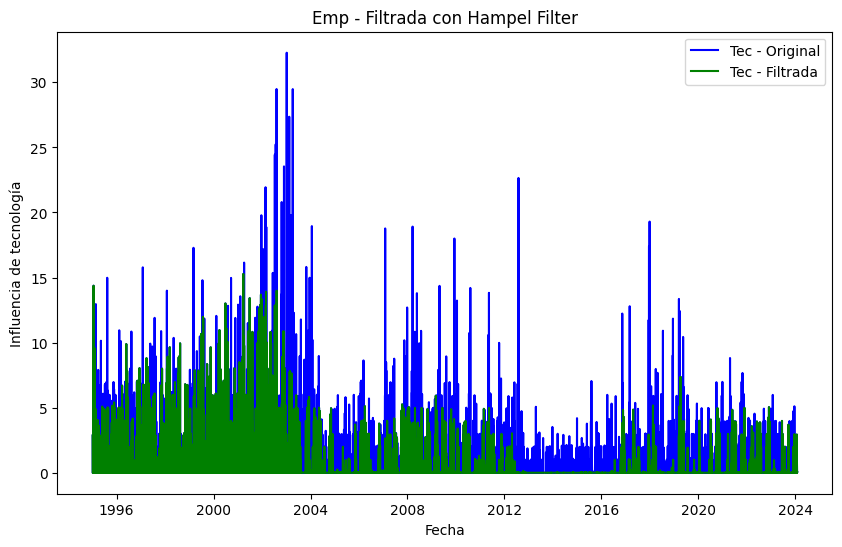

In [91]:
# Aplicar el Hampel Filter a los datos del S&P 500
result = hampel(emp_data['empleo_sum'], window_size=27, n_sigma=3.0).filtered_data

result.index = emp_data.index[:len(result)]
emp_data['Filtered_Value']= result

# Graficar la serie original y la serie filtrada
plt.figure(figsize=(10, 6))
plt.plot( emp_data['empleo_sum'], label='Tec - Original', color='blue')
plt.plot(emp_data['Filtered_Value'], label='Tec - Filtrada', color='green')
plt.title('Emp - Filtrada con Hampel Filter')
plt.xlabel('Fecha')
plt.ylabel('Influencia de tecnología')
plt.legend()
plt.show()

In [92]:
# Calcular la diferencia entre las dos series
difference = emp_data['Filtered_Value'] - emp_data['empleo_sum']
difference_clean = difference.dropna()

print(difference_clean)

Fecha_Publicacion
1995-01-04    1.057051e-07
1995-01-05    0.000000e+00
1995-01-08    0.000000e+00
1995-01-11    0.000000e+00
1995-01-13    2.905662e-17
                  ...     
2024-01-25    5.550100e-08
2024-01-26    9.673386e-09
2024-01-27    2.978686e-08
2024-01-28    0.000000e+00
2024-01-30    1.085937e-09
Length: 7808, dtype: float64


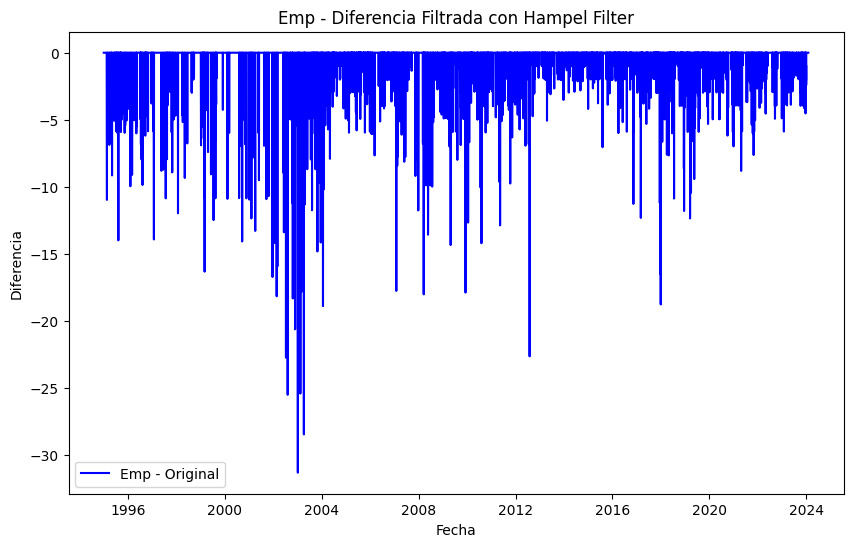

In [93]:
plt.figure(figsize=(10, 6))
plt.plot( difference_clean, label='Emp - Original', color='blue')
plt.title('Emp - Diferencia Filtrada con Hampel Filter')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.legend()
plt.show()

In [96]:
epsilon = 1e-6
emp_data['returnsHF'] = emp_data['Filtered_Value'].pct_change()

emp_data['returnsHF'].replace([np.inf, -np.inf], np.nan, inplace=True)
emp_data.dropna(inplace=True)
emp_data['returnsHF']

,returnsHF
Fecha_Publicacion,
1995-01-15,-1.000000
1995-01-19,-0.795526
1995-01-20,2.011196
1995-01-21,-0.874420
1995-01-22,-1.000000
...,...
2024-01-21,-1.000000
2024-01-25,-0.403548
2024-01-26,-0.436600


In [98]:
emp_data['sq_returnsHF'] = emp_data['returnsHF'].mul(emp_data['returnsHF'])

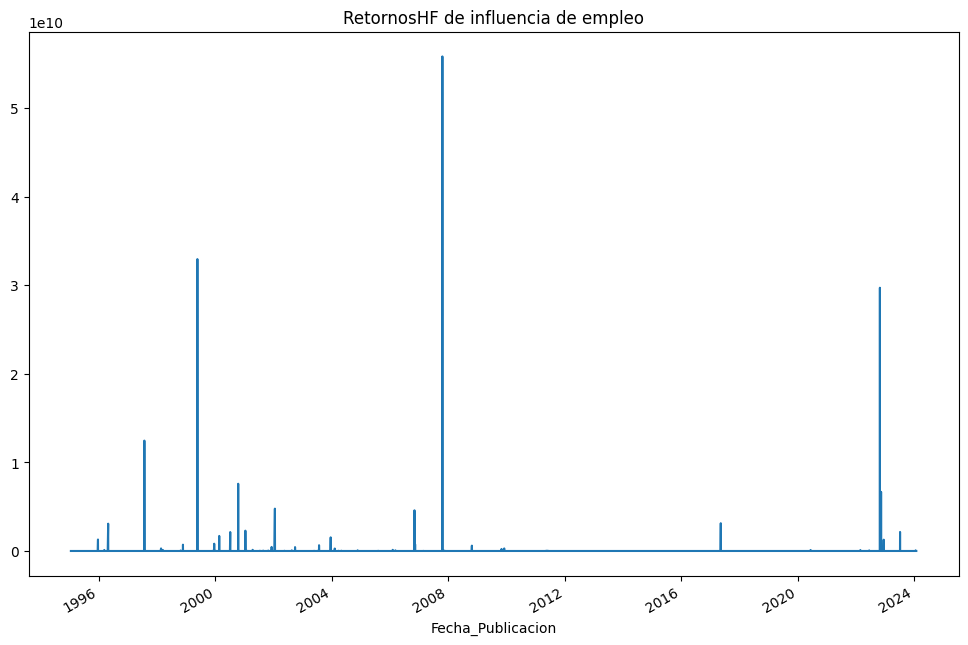

In [99]:
plt.figure(figsize=(12,8))
emp_data['sq_returnsHF'].plot()
plt.title('RetornosHF de influencia de empleo')
plt.show()

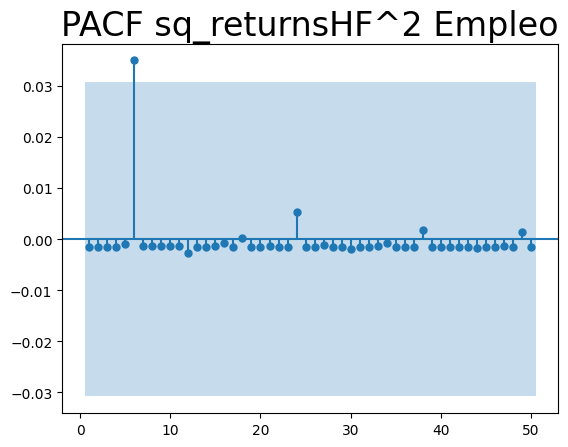

In [100]:
sgt.plot_pacf(emp_data['sq_returnsHF'][1:], lags = 50, zero = False)
plt.title("PACF sq_returnsHF^2 Empleo", size = 24)
plt.autoscale()
plt.show()

In [102]:
model = arch.arch_model(emp_data['returnsHF'][1:],  vol="GARCH", p=1, q=1, rescale=True)
split_date = dt.datetime(2021,1,1)
results = model.fit(last_obs=split_date)
print(results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 29691.951597837622
Iteration:      2,   Func. Count:     13,   Neg. LLF: 19866.481655403404
Iteration:      3,   Func. Count:     18,   Neg. LLF: 19866.477130622097
Iteration:      4,   Func. Count:     23,   Neg. LLF: 20415.891424069046
Iteration:      5,   Func. Count:     31,   Neg. LLF: 19866.474087934865
Iteration:      6,   Func. Count:     35,   Neg. LLF: 19866.47408793485
Optimization terminated successfully    (Exit mode 0)
            Current function value: 19866.474087934865
            Iterations: 7
            Function evaluations: 35
            Gradient evaluations: 6
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              returnsHF   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -19866.5
Distribution:                  Normal  

Tras aplicar el filtro de Hampel a la serie de empleo, los valores atípicos se suavizan, eliminando picos extremos que podrían distorsionar la estimación de la volatilidad. Al ajustar el modelo GARCH(1,1) sobre la serie filtrada, se observa que la media esperada es de 4.44, reflejando un nivel promedio de cambios relativamente estable en la serie.

En cuanto a la volatilidad, los parámetros α₁ y β₁ resultan prácticamente nulos o no significativos, lo que indica que la serie filtrada no muestra efectos persistentes de volatilidad; los cambios extremos anteriores no tienen influencia notable en los futuros. Esto se interpreta como que, una vez eliminados los outliers, la serie de empleo se comporta de manera más estable y menos “reactiva” a fluctuaciones puntuales, haciendo que la variabilidad sea más predecible y menos extrema que en la serie original.

La volatilidad observada en la serie original de Empleo era producto de eventos extremos (outliers). Al suavizar la serie, el modelo GARCH deja de ser necesario o efectivo, indicando que la serie 'normal' (sin eventos extremos) tiene una varianza constante.

In [103]:
pred_model=results.forecast(horizon = 2, align='target')

data1_standardized = (emp_data['returnsHF'][split_date:] - emp_data['returnsHF'][split_date:].mean()) / emp_data['returnsHF'][split_date:].std()
data2_standardized = (pred_model.residual_variance - pred_model.residual_variance.mean()) / pred_model.residual_variance.std()


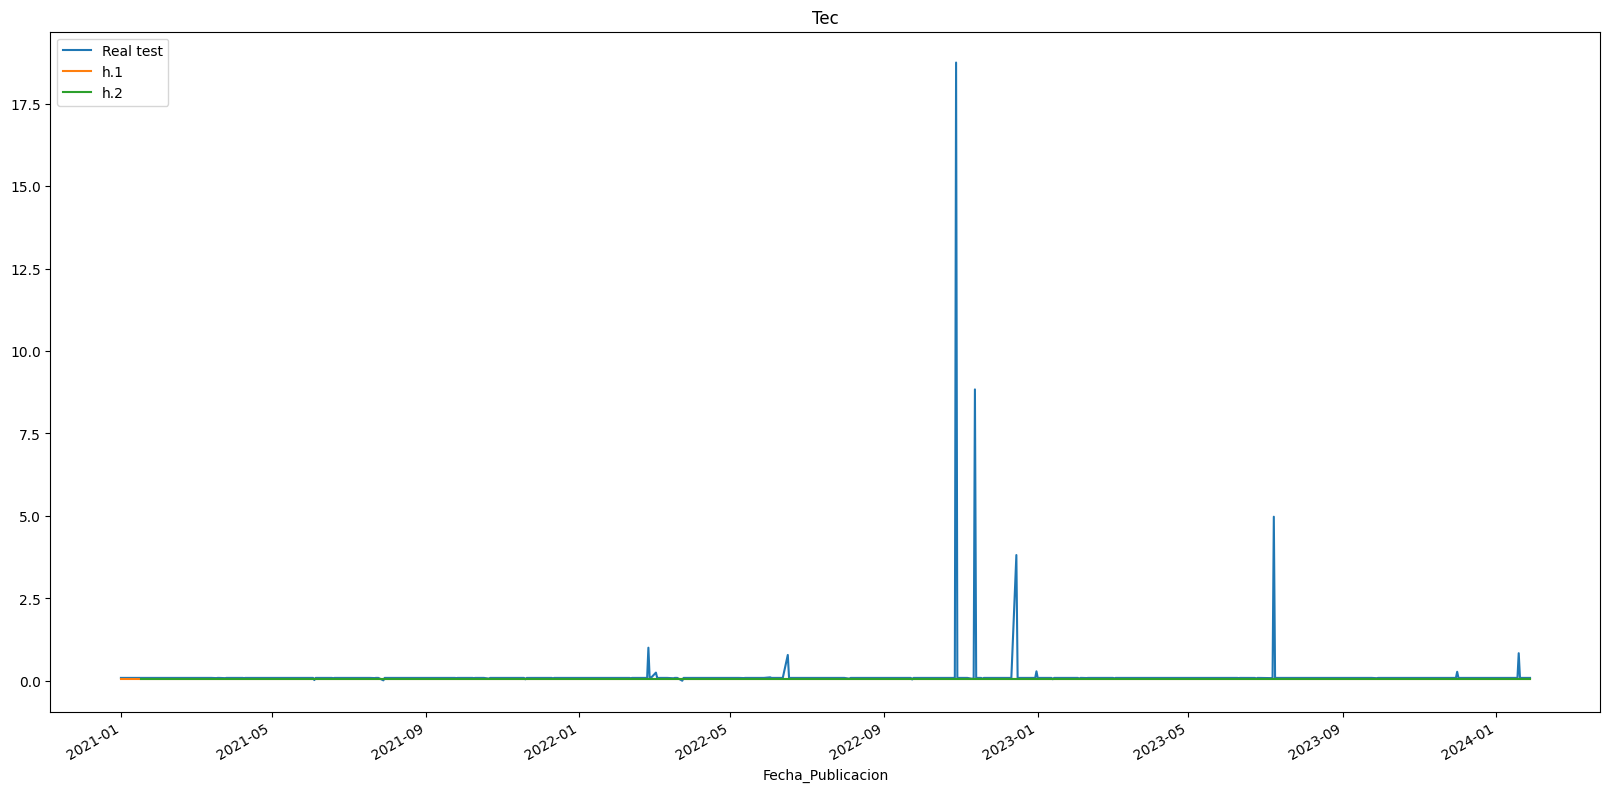

In [104]:
fig, ax = plt.subplots()
data1_standardized.abs().plot(ax=ax,figsize=(20,10), title = "Emp", label='Real test', zorder=1)
data2_standardized.abs().plot(ax=ax,figsize=(20,10),zorder = 2)
plt.legend(loc="upper left")

In [105]:
volatility_forecast = pred_model.variance[-1:].values[0][0] ** 0.5  # Desviación estándar
mean_forecast = pred_model.mean[-1:].values[0][0]  # Media esperada
print(f"Pronóstico para mañana:")
print(f"Media esperada: {mean_forecast:.4f}")
print(f"Volatilidad esperada: {volatility_forecast:.4f}%")

Pronóstico para mañana:
Media esperada: 4.4424
Volatilidad esperada: 62.5247%


Aunque la media de la serie de empleo filtrada se mantiene estable, la volatilidad prevista sigue siendo alta. Esto se debe a que, si bien se han eliminado los valores atípicos más extremos, la serie aún conserva episodios de cambios relativamente marcados que hacen que la variabilidad futura pueda ser significativa.

# Conclusiones

El análisis de tecnlogía muestra que la media de los retornos es positiva, esto indica que, si bien existe una inercia diaria hacia el crecimiento, la serie es altamente intermitente y volátil.

Por su parte, la serie de empleo muestra una estructura de volatilidad que, tras el filtrado, pierde su persistencia. Esto implica que los movimientos futuros en la influencia del empleo, aunque seguirán una tendencia a la baja, serán más irregulares y aleatorios (ruido blanco) de lo que sugerían los picos extremos de la serie original.

# Tendencia Anual (30 datos)

Como solo tenemos 30 datos para datos anuales, vamos a hacer una regresión lineal simple



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

anual = pd.read_csv("../data/indicators/indicators_madrid_annual.csv", sep=",")
anual.head()

,Fecha_Publicacion,total_count,economía_count,empleo_count,salud_count,tecnología_count,empleo_sum,economía_sum,tecnología_sum,salud_sum,publica,privada
0,1995-12-31,1058,40,832,15,171,614.702511,37.095372,83.242686,14.635310,1053,1
1,1996-12-31,1248,50,950,24,224,703.325013,40.392958,134.121426,15.649202,1236,1
2,1997-12-31,1237,42,983,18,194,699.937426,33.881522,117.158139,7.368413,1221,13
3,1998-12-31,1296,56,992,16,232,738.802035,34.849798,152.804692,6.409144,1262,23
4,1999-12-31,1574,59,1191,45,279,806.354569,30.892468,182.758671,8.175997,1534,22


In [ ]:
anual = anual[['Fecha_Publicacion','tecnología_sum', 'empleo_sum']]
anual['Fecha_Publicacion'] = pd.to_datetime(anual['Fecha_Publicacion'])
anual['year'] = anual['Fecha_Publicacion'].dt.year
print(anual.head())

  Fecha_Publicacion  tecnología_sum  empleo_sum  year
0        1995-12-31       83.242686  614.702511  1995
1        1996-12-31      134.121426  703.325013  1996
2        1997-12-31      117.158139  699.937426  1997
3        1998-12-31      152.804692  738.802035  1998
4        1999-12-31      182.758671  806.354569  1999


In [ ]:
slope_tec, intercept_tec, r_value, p_value, std_err = linregress(anual['year'], anual['tecnología_sum'])
print(f"Tecnología: pendiente anual = {slope_tec:.4f}, p-valor = {p_value:.4f}")

Tecnología: pendiente anual = -0.8506, p-valor = 0.3044


In [ ]:
slope_emp, intercept_emp, r_value, p_value, std_err = linregress(anual['year'], anual['empleo_sum'])
print(f"Empleo: pendiente anual = {slope_emp:.4f}, p-valor = {p_value:.4f}")

Empleo: pendiente anual = -23.8645, p-valor = 0.0000


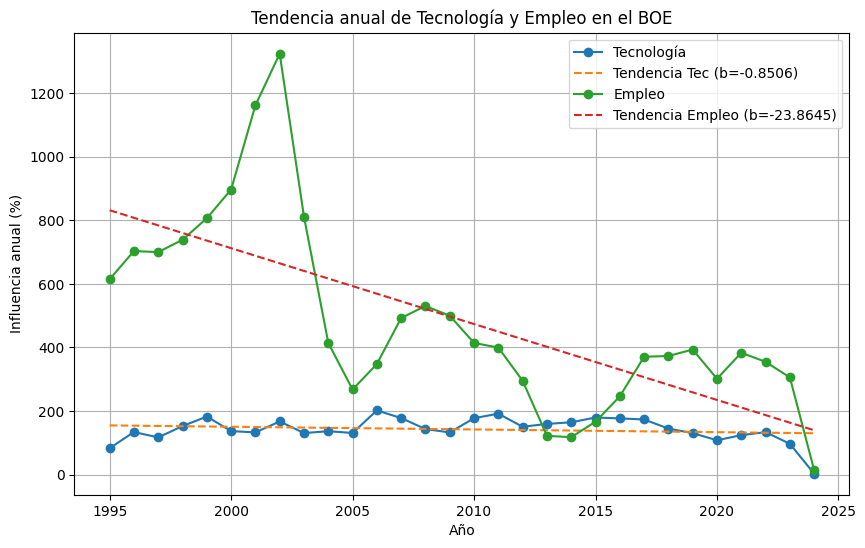

In [ ]:
# Graficar
plt.figure(figsize=(10,6))
# Tecnología
plt.plot(anual['year'], anual['tecnología_sum'], 'o-', label='Tecnología')
plt.plot(anual['year'], intercept_tec + slope_tec*anual['year'], '--', label=f'Tendencia Tec (b={slope_tec:.4f})')
# Empleo
plt.plot(anual['year'], anual['empleo_sum'], 'o-', label='Empleo')
plt.plot(anual['year'], intercept_emp + slope_emp*anual['year'], '--', label=f'Tendencia Empleo (b={slope_emp:.4f})')

plt.xlabel('Año')
plt.ylabel('Influencia anual (%)')
plt.title('Tendencia anual de Tecnología y Empleo en el BOE')
plt.legend()
plt.grid(True)
plt.show()

La pendiente anual de la influencia de tecnología ha disminuido ligeramente (-0.8506) en lugar de aumentar como expresábamos en nuestra hipótesis. Sin embargo, el p-valor es 0.3044, la pendiente no es estadísticamente significativa. Esto refuerza que no hay evidencia clara de aumento anual en la influencia tecnológica en la serie de 1995–2024.

En cuanto al empleo, la pendiente anual de empleo es de -23.8645, es decir, que disminuye fuertemente cada año, más de lo esperado en nuestra hipótesis.
El p-valor = 0.0000 indica que la tendencia decreciente es real y consistente.